In [304]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform

from eyf.clase_ternaria import calcular_clase_ternaria

## CONSTANTES

In [65]:
DATA_PATH = '../data'
RAW_DATA_NAME = 'competencia_01_crudo.csv'
RAW_DATA_PATH = f'{DATA_PATH}/{RAW_DATA_NAME}'
FEATURES_DATA_NAME = 'features.csv'
FEATURES_DATA_PATH = f'{DATA_PATH}/{FEATURES_DATA_NAME}'
RANDOM_SEEDS = [537919, 923347, 173629, 419351, 287887]

# Lectura de datos y generación de clase ternaria

In [66]:
df = pd.read_csv(RAW_DATA_PATH)
df = calcular_clase_ternaria(df)

/Users/frjofre/Documents/EyF/eyf/src/eyf/clase_ternaria.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clientes["clase_ternaria"] = "CONTINUA"


# Exploración inicial

## Tarjetas de crédito

In [67]:
master_columns = df.columns[df.columns.str.contains("Master", case=False)]

In [68]:
visa_columns = df.columns[df.columns.str.contains("Visa", case=False)]


### Feature Engineering

In [69]:
df["consumo_por_transaccion_visa"] = df["mtarjeta_visa_consumo"] / df["ctarjeta_visa_transacciones"]
df["consumo_por_transaccion_visa"] = df["consumo_por_transaccion_visa"]
df["consumo_por_transaccion_master"] = df["mtarjeta_master_consumo"] / df["ctarjeta_master_transacciones"]

df["ratio_descuento_visa"] = df["ctarjeta_visa_descuentos"] / df["ctarjeta_visa_transacciones"]
df["ratio_descuento_master"] = df["ctarjeta_master_descuentos"] / df["ctarjeta_master_transacciones"]
df["ratio_descuento_master"] = df["ratio_descuento_master"].replace([np.inf, -np.inf], np.nan)

df["ratio_consumo_limite_visa"] = df['Visa_mconsumototal'] / df['Visa_mlimitecompra']
df["ratio_consumo_limite_master"] = df['Master_mconsumototal'] / df['Master_mlimitecompra']

'''df["ratio_debito_automatico_visa"] = df["ctarjeta_visa_debitos_automaticos"] / df["ctarjeta_visa_transacciones"]
df["ratio_debito_automatico_master"] = df["ctarjeta_master_debitos_automaticos"] / df["ctarjeta_master_transacciones"]

df["ratio_dolares_visa"] = df["Visa_mconsumospesos"] / df["Visa_mconsumosdolares"]
df["ratio_dolares_master"] = df["Master_mconsumospesos"] / df["Master_mconsumosdolares"]'''


'df["ratio_debito_automatico_visa"] = df["ctarjeta_visa_debitos_automaticos"] / df["ctarjeta_visa_transacciones"]\ndf["ratio_debito_automatico_master"] = df["ctarjeta_master_debitos_automaticos"] / df["ctarjeta_master_transacciones"]\n\ndf["ratio_dolares_visa"] = df["Visa_mconsumospesos"] / df["Visa_mconsumosdolares"]\ndf["ratio_dolares_master"] = df["Master_mconsumospesos"] / df["Master_mconsumosdolares"]'

## Cliente

In [70]:
cliente_columns = ["numero_de_cliente", "active_quarter", "cliente_vip", "internet", "cliente_edad", "cliente_antiguedad"]

## Ganancias del banco

In [71]:
ganancia_columns = ["mrentabilidad", "mrentabilidad_annual", "mcomisiones", "mactivos_margen", "mpasivos_margen"]

### Feature Engineering

In [72]:
df["ratio_rentabilidad"] = df["mrentabilidad"] / df["mrentabilidad_annual"]
df["margen_neto"] = df["mactivos_margen"] - df["mpasivos_margen"]
df["ratio_margen"] = df["mactivos_margen"] / df["mpasivos_margen"]
df["ratio_margen"] = df["ratio_margen"].replace([np.inf, -np.inf], np.nan)
df["rentabilidad_operativa"] = df["mrentabilidad"] - df["mcomisiones"]
df["rent/antiguedad"] = df["mrentabilidad_annual"] / df["cliente_antiguedad"]

## Cuenta corriente

In [73]:
cuenta_corriente_columns = list(df.columns[df.columns.str.contains("corriente", case=False)]) + ["cdescubierto_preacordado"]

In [152]:
cuenta_corriente_columns

['ccuenta_corriente',
 'mcuenta_corriente_adicional',
 'mcuenta_corriente',
 'cdescubierto_preacordado']

## Caja de ahorro

In [74]:
caja_ahorro_columns = list(df.columns[df.columns.str.contains("ahorro", case=False)]) + ['cpayroll_trx', 'mpayroll', 'mpayroll2', 'cpayroll2_trx']

In [75]:
df["ratio_payroll"] = (df["mcaja_ahorro"] + df["mcaja_ahorro_adicional"])/ (df["mpayroll"] + df["mpayroll2"])
df["ratio_payroll"] = df["ratio_payroll"].replace([np.inf, -np.inf], np.nan)

## Prestamos

In [76]:
prestamos_columns = df.columns[df.columns.str.contains("prestamo", case=False)]

In [77]:
df["cprestamos"] = df["cprestamos_prendarios"] + df["cprestamos_hipotecarios"] + df["cprestamos_personales"]
df["mprestamos"] = df["mprestamos_prendarios"] + df["mprestamos_hipotecarios"] + df["mprestamos_personales"]

## Inversiones

In [78]:
inversiones_columns = list(df.columns[df.columns.str.contains("inversion", case=False)]) + list(df.columns[df.columns.str.contains("plazo_fijo", case=False)])

In [79]:
df["cinversiones"] = df["cinversion1"] + df["cinversion2"] + df["cplazo_fijo"]
df["minversiones_pesos"] = df["minversion1_pesos"] + df["minversion2"] + df["mplazo_fijo_pesos"]
df["minversiones_dolares"] = df["minversion1_dolares"]  + df["mplazo_fijo_dolares"]

df["ratio_inversion1_pesos"] = df["minversion1_pesos"] / df["minversiones_pesos"]
df["ratio_inversion2"] = df["minversion2"] / df["minversiones_pesos"]
df["ratio_plazo_fijo_pesos"] = df["mplazo_fijo_pesos"] / df["minversiones_pesos"]

df["ratio_inversion1_dolares"] = df["minversion1_dolares"] / df["minversiones_dolares"]
df["ratio_plazo_fijo_dolares"] = df["mplazo_fijo_dolares"] / df["minversiones_dolares"]

## Seguros

In [80]:
seguros_columns = list(df.columns[df.columns.str.contains("seguro", case=False)])

In [81]:
df["cseguros"] = df["cseguro_vida"] + df["cseguro_auto"] + df["cseguro_vivienda"] + df["cseguro_accidentes_personales"]


## Otros

In [82]:
otros_columns = ["ccaja_seguridad", 'ccuenta_debitos_automaticos', 'mcuenta_debitos_automaticos', 'ccajeros_propios_descuentos', 'mcajeros_propios_descuentos']

## Pago de servicios

In [83]:
servicios_columns = ['cpagodeservicios', 'mpagodeservicios', 'cpagomiscuentas', 'mpagomiscuentas']

## Moneda extranjera

In [84]:
forex_columns = list(df.columns[df.columns.str.contains("forex", case=False)])

## Transferencias

In [85]:
transferencias_columns = list(df.columns[df.columns.str.contains("transferencia", case=False)])


In [ ]:
df["ratio_transferencias"] = df["mtransferencias_recibidas"] / df["mtransferencias_emitidas"]
df["ratio_transferencias"] = df["ratio_transferencias"].replace([np.inf, -np.inf], np.nan)
df["promedio_recibido"] = df["mtransferencias_recibidas"] / df["ctransferencias_recibidas"]
df["promedio_emitido"] = df["mtransferencias_emitidas"] / df["ctransferencias_emitidas"]

## Cheques

In [87]:
cheques_columns = list(df.columns[df.columns.str.contains("cheque", case=False)])

In [88]:
df["ratio_cheques"] = df["mcheques_depositados"] / df["mcheques_emitidos"]
df["ratio_cheques"] = df["ratio_cheques"].replace([np.inf, -np.inf], np.nan)
df["promedio_depositados"] = df["mcheques_depositados"] / df["ccheques_depositados"]
df["promedio_emitidos"] = df["mcheques_emitidos"] / df["ccheques_emitidos"]

df["ratio_depositados_rechazados"] = df["ccheques_depositados_rechazados"] / df["ccheques_depositados"]
df["ratio_emitidos_rechazados"] = df["ccheques_emitidos_rechazados"] / df["ccheques_emitidos"]

## Extracciones

In [89]:
extracciones_columns = list(df.columns[df.columns.str.contains("extraccion", case=False)])

In [90]:
df["promedio_extraccion_autoservicio"] = df["mextraccion_autoservicio"] / df["cextraccion_autoservicio"]

## Transacciones

In [91]:
transacciones_columns = list(df.columns[94:110])

In [92]:
canales = [
    'ccallcenter_transacciones',
    'chomebanking_transacciones',
    'ccajas_transacciones',
    'catm_trx',
    'catm_trx_other',
    'cmobile_app_trx'
]
df['canal_preferido'] = df[canales].idxmax(axis=1)
df['canal_preferido'] = df['canal_preferido'].str.replace('_transacciones','')

## Features temporales

In [93]:
import pandas as pd
import numpy as np
from functools import reduce
from tqdm import tqdm

def temporal_features_multiple(df, columns, foto_mes_target, n_months=3):
    """
    Genera features temporales para múltiples columnas para un mes objetivo,
    calculando sum, mean, max, min, std y momentum, y además suma total de cada tipo.

    Args:
        df: DataFrame con columnas 'numero_de_cliente', 'foto_mes' y las columnas a procesar
        columns: lista de columnas a procesar
        foto_mes_target: int, mes objetivo (ej: 202106)
        n_months: int, cantidad de meses atrás a considerar

    Returns:
        df_features: DataFrame listo para mergear con df original
    """

    # Definir el rango de meses a usar
    meses_usar = sorted([m for m in df['foto_mes'].unique()
                         if foto_mes_target - n_months + 1 <= m <= foto_mes_target])

    # Filtrar DataFrame
    df_window = df[df['foto_mes'].isin(meses_usar)].copy()

    # Función para calcular momentum
    def momentum(x):
        x_sorted = x.sort_index()
        if len(x_sorted) <= 1:
            return 0
        return x_sorted.iloc[-1] - x_sorted.iloc[:-1].mean()

    # Diccionario para resultados
    dfs = []

    # Procesar cada columna
    for col in tqdm(columns):
        df_agg = df_window.groupby('numero_de_cliente')[col].agg(
            sum_= 'sum',
            mean_= 'mean',
            max_= 'max',
            min_= 'min',
            std_= 'std',
            #momentum_= momentum
        ).reset_index()

        # Renombrar columnas con prefijo
        df_agg = df_agg.rename(columns={c: f"{col}_{c}" for c in df_agg.columns if c != 'numero_de_cliente'})
        dfs.append(df_agg)

    # Merge de todas las columnas
    df_features = reduce(lambda left,right: pd.merge(left, right, on='numero_de_cliente'), dfs)

    # Agregar columna de foto_mes
    df_features['foto_mes'] = foto_mes_target

    return df_features


In [94]:
features = ['ctarjeta_visa_transacciones', 'mtarjeta_visa_consumo',
 'Visa_cadelantosefectivo', 'Visa_mfinanciacion_limite',
 'Visa_mpagado', "mrentabilidad", "mcomisiones",
 "mpasivos_margen", "mactivos_margen", "margen_neto",
 "rentabilidad_operativa", "mcuenta_corriente", "mcaja_ahorro",
 "mprestamos", "minversiones_pesos", "minversiones_dolares", "mforex_buy",
 "mforex_sell", "mtransferencias_recibidas", "mtransferencias_emitidas",
 "promedio_depositados", "promedio_emitidos", "promedio_extraccion_autoservicio",]


In [95]:
df_copy = df.copy()

In [ ]:
df = df_copy.copy()

In [ ]:
RECALCULATE_FEATURES = False
DO_FEATURE_EXISTS = os.path.exists(FEATURES_DATA_PATH)
if not DO_FEATURE_EXISTS or RECALCULATE_FEATURES:
  foto_meses = [202104, 202105, 202106]
  for foto_mes in foto_meses:
    print(foto_mes)
    df_features_temporales = temporal_features_multiple(df, features, foto_mes)
    df = pd.merge(df, df_features_temporales, on=['numero_de_cliente', 'foto_mes'], how='left')
else:
  #df = pd.read_csv(FEATURES_DATA_PATH)


202104


100%|██████████| 23/23 [00:00<00:00, 50.36it/s]


202105


100%|██████████| 23/23 [00:00<00:00, 58.31it/s]


202106


100%|██████████| 23/23 [00:00<00:00, 53.64it/s]


In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,cseguros,ratio_transferencias,promedio_recibido,promedio_emitido,ratio_cheques,promedio_depositados,promedio_emitidos,ratio_depositados_rechazados,ratio_emitidos_rechazados,promedio_extraccion_autoservicio
count,1.634180e+05,163418.0,163418.000000,163418.000000,163418.000000,163418.000000,163418.000000,163418.000000,1.634180e+05,163418.000000,...,163418.000000,9.771600e+04,1.201440e+05,9.771600e+04,4154.000000,5.703000e+03,4.154000e+03,5703.000000,4154.000000,83099.000000
mean,7.720350e+08,202104.0,0.987351,0.002338,0.062686,46.892380,134.238890,1920.779234,2.386172e+04,1389.534564,...,0.423258,7.245229e+01,5.175271e+04,2.250600e+04,1.664921,8.623298e+04,6.273348e+04,0.022180,0.026879,9846.519725
std,3.231732e+08,0.0,0.111753,0.048292,0.314405,12.952085,85.979944,8395.003193,6.615610e+04,2663.926705,...,0.711599,1.742222e+04,4.488997e+05,1.094786e+06,12.486899,2.676781e+05,1.440542e+05,0.135249,0.134768,8013.711405
min,2.492213e+08,202104.0,0.000000,0.000000,0.000000,18.000000,1.000000,-602558.400000,-5.798083e+06,-350964.690000,...,0.000000,0.000000e+00,1.000000e-02,1.000000e-02,0.000000,1.925000e+02,5.865000e+01,0.000000,0.000000,117.300000
25%,5.188488e+08,202104.0,1.000000,0.000000,0.000000,37.000000,62.000000,-109.877500,1.843180e+03,335.510000,...,0.000000,2.641396e-01,8.578400e+03,4.105500e+03,0.000000,1.748738e+04,1.509152e+04,0.000000,0.000000,4301.000000
50%,7.337196e+08,202104.0,1.000000,0.000000,0.000000,45.000000,127.000000,1126.795000,1.277340e+04,909.455000,...,0.000000,1.556483e+00,2.189600e+04,8.398680e+03,0.000000,3.519000e+04,2.932500e+04,0.000000,0.000000,7038.000000
75%,1.000959e+09,202104.0,1.000000,0.000000,0.000000,56.000000,189.000000,2859.750000,3.076122e+04,1993.725000,...,1.000000,4.796283e+00,4.931365e+04,1.730175e+04,0.101115,7.741800e+04,5.865000e+04,0.000000,0.000000,12707.500000
max,1.592903e+09,202104.0,1.000000,1.000000,4.000000,99.000000,376.000000,798611.710000,4.999534e+06,378033.950000,...,7.000000,5.442020e+06,1.146868e+08,3.413430e+08,537.190398,9.741712e+06,3.471545e+06,4.000000,1.500000,58650.000000


In [ ]:
#df.to_csv(FEATURES_DATA_PATH, index=False)

In [131]:
df_last_month = df[(df["foto_mes"]==202105) & (df["clase_ternaria"]=="BAJA+1")]
clientes = df_last_month["numero_de_cliente"].unique()
df_last_month = df_last_month.drop(columns=["numero_de_cliente", "clase_ternaria", "canal_preferido"])

In [109]:
df_last_month.describe()

,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,mactivos_margen,...,cseguros,ratio_transferencias,promedio_recibido,promedio_emitido,ratio_cheques,promedio_depositados,promedio_emitidos,ratio_depositados_rechazados,ratio_emitidos_rechazados,promedio_extraccion_autoservicio
count,1134.0,1134.000000,1134.000000,1134.000000,1134.000000,1134.000000,1134.000000,1134.000000,1134.000000,1134.000000,...,1134.000000,268.000000,4.540000e+02,2.680000e+02,6.000000,7.000000,6.000000,7.0,6.000000,142.000000
mean,202105.0,0.827160,0.001764,0.135802,47.328042,108.666667,2063.110697,18130.271138,1391.669541,251.945926,...,0.165785,775.446856,2.462041e+04,2.953811e+04,0.008502,86275.266429,125088.325106,0.0,0.185185,9463.190780
std,0.0,0.378275,0.041978,0.404178,14.341687,81.196807,5168.913681,31000.920945,1226.646965,4208.903419,...,0.451371,9416.705691,6.760873e+04,1.304986e+05,0.020825,157177.011149,127167.521181,0.0,0.401643,8182.709152
min,202105.0,0.000000,0.000000,0.000000,21.000000,1.000000,-56710.770000,-72355.190000,-6126.940000,-55649.980000,...,0.000000,0.000000,1.170000e+00,1.000000e-02,0.000000,2597.455000,15241.450000,0.0,0.000000,351.900000
25%,202105.0,1.000000,0.000000,0.000000,36.000000,44.000000,318.772500,4153.937500,194.955000,-221.185000,...,0.000000,0.035867,3.098627e+03,2.313698e+03,0.000000,6862.050000,39776.594048,0.0,0.000000,3929.550000
50%,202105.0,1.000000,0.000000,0.000000,45.000000,86.000000,1758.910000,11249.965000,1592.200000,12.585000,...,0.000000,1.008406,8.073270e+03,6.363525e+03,0.000000,29325.000000,83662.381429,0.0,0.000000,5865.000000
75%,202105.0,1.000000,0.000000,0.000000,58.000000,163.000000,2749.032500,23165.512500,2089.570000,378.315000,...,0.000000,3.348244,2.220379e+04,1.580324e+04,0.000000,60258.355000,163527.930000,0.0,0.083333,11730.000000
max,202105.0,1.000000,1.000000,3.000000,92.000000,377.000000,96145.390000,304985.610000,11455.910000,81227.140000,...,3.000000,140760.000000,1.033649e+06,1.778268e+06,0.051010,437763.600000,352665.960000,0.0,1.000000,36538.950000


In [110]:
random_state = RANDOM_SEEDS[0]
X_real = df_last_month.values
n_samples, n_features = X_real.shape

X_synth = np.zeros_like(X_real)
for j in range(n_features):
    X_synth[:, j] = np.random.choice(X_real[:, j], size=n_samples, replace=True)
X = np.vstack([X_real, X_synth])
y = np.hstack([np.ones(n_samples), np.zeros(n_samples)])  # 1=real, 0=ficticio

X, y = shuffle(X, y, random_state=random_state) # por las dudas

In [ ]:
from sklearn.ensemble import RandomForestClassifier



,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [165]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans

def plot_silhouette_from_distance(D, labels):
    """
    Calcula y grafica el silhouette plot usando matriz de distancias.
    
    Parámetros:
    -----------
    D : array-like, shape (n_samples, n_samples)
        Matriz de distancias (simétrica, ceros en la diagonal).
    labels : array-like
        Etiquetas de cluster asignadas a cada fila.
    """
    # Calcular promedio general
    silhouette_avg = silhouette_score(D, labels, metric="precomputed")
    print(f"Silhouette Score promedio: {silhouette_avg:.3f}")

    # Calcular valores individuales
    sample_silhouette_values = silhouette_samples(D, labels, metric="precomputed")

    n_clusters = len(np.unique(labels))
    y_lower = 10
    fig, ax1 = plt.subplots(figsize=(8, 6))

    for i in range(n_clusters):
        i+=1
        # Silhouette values de este cluster
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab10(i % 10)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title("Silhouette Plot (distancias precomputadas)")
    ax1.set_xlabel("Coeficiente de Silhouette")
    ax1.set_ylabel("Cluster")

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")


    plt.show()

In [113]:
def calculate_proximity_matrix(model, X, normalize=True):
    """
    Calculates the proximity matrix for a Random Forest model.

    Args:
        model: A trained RandomForestClassifier or RandomForestRegressor.
        X: The input data used for training or prediction.
        normalize: If True, normalize the proximity matrix by the number of trees.

    Returns:
        A NumPy array representing the proximity matrix.
    """
    # Get the terminal node index for each sample in each tree
    terminals = model.apply(X)
    n_trees = terminals.shape[1]
    n_samples = terminals.shape[0]

    # Initialize proximity matrix
    proximity_matrix = np.zeros((n_samples, n_samples))

    # Calculate shared leaf nodes for all pairs
    for i in range(n_trees):
        # For each tree, find pairs that land in the same leaf
        tree_terminals = terminals[:, i]
        for j in range(n_samples):
            for k in range(j, n_samples): # Avoid redundant calculations
                if tree_terminals[j] == tree_terminals[k]:
                    proximity_matrix[j, k] += 1
                    if j != k: # Ensure symmetry
                        proximity_matrix[k, j] += 1

    if normalize:
        proximity_matrix /= n_trees

    return proximity_matrix

OOB score: 0.9889770723104057
OOB misclassification rate: 0.011022927689594342
Silhouette Score promedio: 0.155


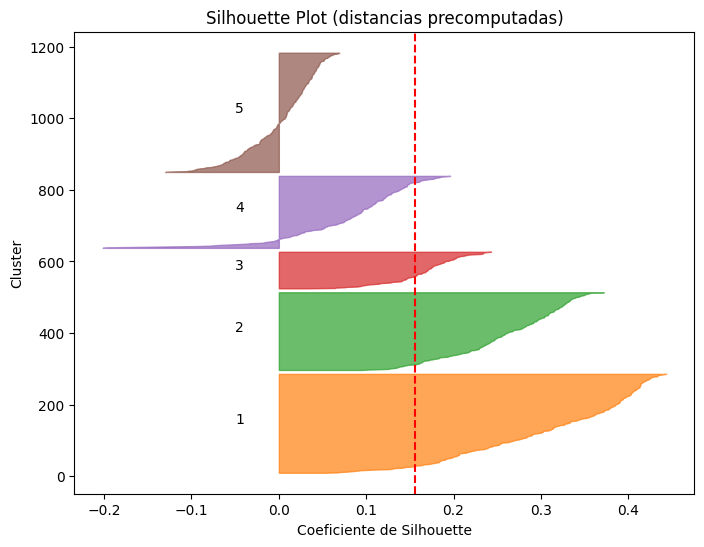

In [187]:
random_state = RANDOM_SEEDS[0]

rf = RandomForestClassifier(max_depth=10, random_state=random_state, oob_score=True, min_samples_leaf=50)
rf.fit(X, y)
print("OOB score:", rf.oob_score_)
print("OOB misclassification rate:", 1 - rf.oob_score_)
proximity_matrix = calculate_proximity_matrix(rf, X_real)
distance_matrix = 1 - proximity_matrix
condensed = squareform(distance_matrix)
# 1. Calcular el linkage (método de agrupamiento)
Z = linkage(condensed, method='ward')  # 'single', 'complete', 'ward', etc.
# 3. Cortar el dendrograma para obtener clusters
labels = fcluster(Z, t=5, criterion="maxclust")
plot_silhouette_from_distance(distance_matrix, labels)



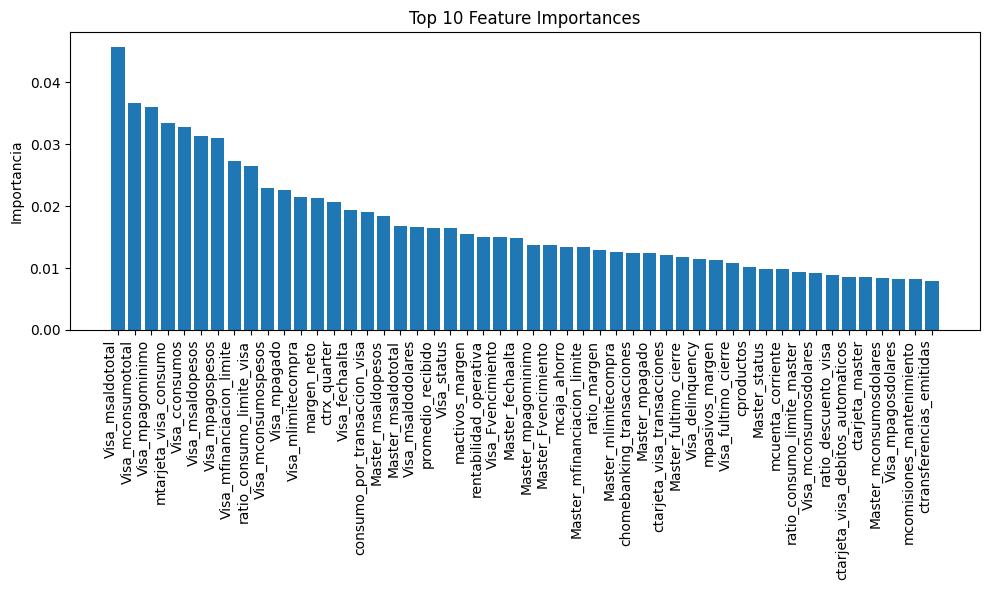

In [190]:
import matplotlib.pyplot as plt
import numpy as np

importancias = rf.feature_importances_
nombres_columnas = df_last_month.columns

# Ordenar las importancias de mayor a menor y tomar las 10 primeras
indices = np.argsort(importancias)[::-1][:50]

plt.figure(figsize=(10,6))
plt.bar(range(50), importancias[indices], align="center")
plt.xticks(range(50), [nombres_columnas[i] for i in indices], rotation=90, ha="right")
plt.title("Top 10 Feature Importances")
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()

In [191]:
df_last_month["cluster_label"] = labels
df_last_month["cluster_label"].value_counts()


cluster_label
5    334
1    277
2    218
4    202
3    103
Name: count, dtype: int64

In [125]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_variable_history(df, value_col, group_col=None, date_col="foto_mes"):
    """
    Grafica la historia de una variable agrupada siempre por foto_mes 
    y opcionalmente por otra columna adicional.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame con los datos
    value_col : str
        Columna numérica a graficar
    group_col : str, opcional
        Columna categórica para agrupar además de foto_mes
    date_col : str, default "foto_mes"
        Columna de fechas/meses
    """
    
    # Definir agrupación
    groupby_cols = [date_col] + ([group_col] if group_col else [])
    
    # Calcular estadísticas
    stats = df.groupby(groupby_cols)[value_col].agg(
        ["mean", "median", "min", "max"]
    ).reset_index()
    
    # Crear figura
    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
    stat_names = ["mean", "median", "min", "max"]

    for ax, stat in zip(axes, stat_names):
        if group_col:
            for key, grp in stats.groupby(group_col):
                ax.plot(grp[date_col], grp[stat], marker="o", label=f"{group_col}={key}")
            ax.legend()
        else:
            ax.plot(stats[date_col], stats[stat], marker="o", label=stat)
        
        ax.set_title(f"{stat} of {value_col}")
        ax.set_ylabel(stat)
    
    plt.xlabel(date_col)
    plt.tight_layout()
    plt.show()


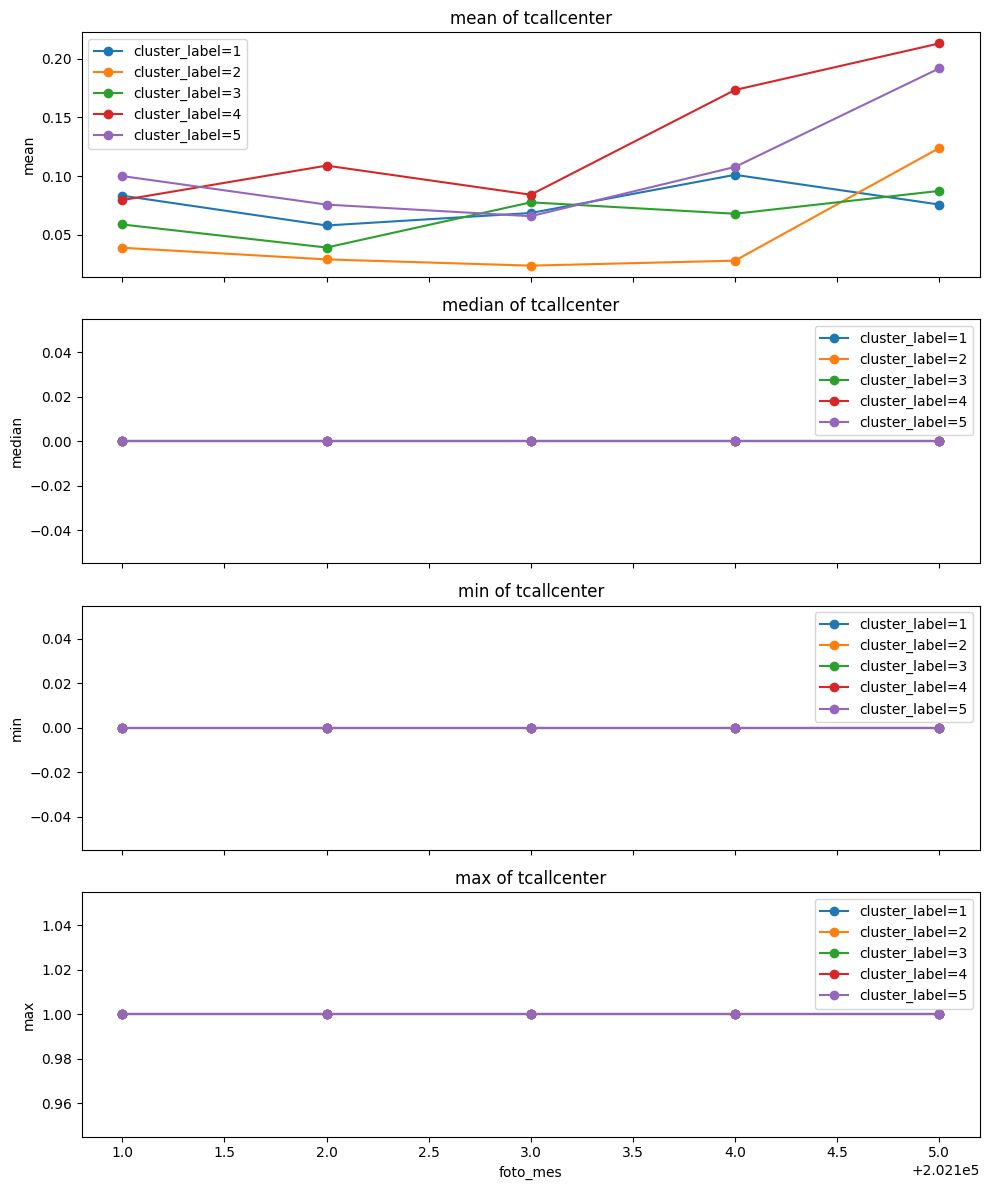

In [342]:
df_last_month["numero_de_cliente"] = clientes
df_last_month_history = df[df["numero_de_cliente"].isin(clientes)]
df_last_month_history = pd.merge(df_last_month[["numero_de_cliente", "cluster_label"]], df_last_month_history, on="numero_de_cliente", how="left")
plot_variable_history(df_last_month_history, "tcallcenter", "cluster_label")


In [307]:
def plot_grouped_histogram(df, value_col, group_col, bins=30, figsize=(10,6), alpha=0.7, xlim=None):
    """
    Grafica histogramas de una columna agrupados por otra columna en formato línea (densidad).
    
    Args:
        df (pd.DataFrame): DataFrame con los datos
        value_col (str): Columna a graficar
        group_col (str): Columna por la que se agrupan los datos
        bins (int): Cantidad de bins para el histograma
        figsize (tuple): Tamaño de la figura
        alpha (float): Transparencia de las líneas
        xlim (tuple, opcional): Límite del eje x, por ejemplo (xmin, xmax)
    """
    plt.figure(figsize=figsize)
    
    groups = df[group_col].unique()
    for g in groups:
        subset = df[df[group_col] == g][value_col].dropna()
        sns.kdeplot(subset, label=str(g), fill=False, bw_adjust=1)  # Línea KDE
    
    plt.xlabel(value_col)
    plt.ylabel("Densidad")
    plt.title(f"Distribución de {value_col} agrupada por {group_col}")
    plt.legend(title=group_col)
    if xlim is not None:
        plt.xlim(xlim)
    plt.show()

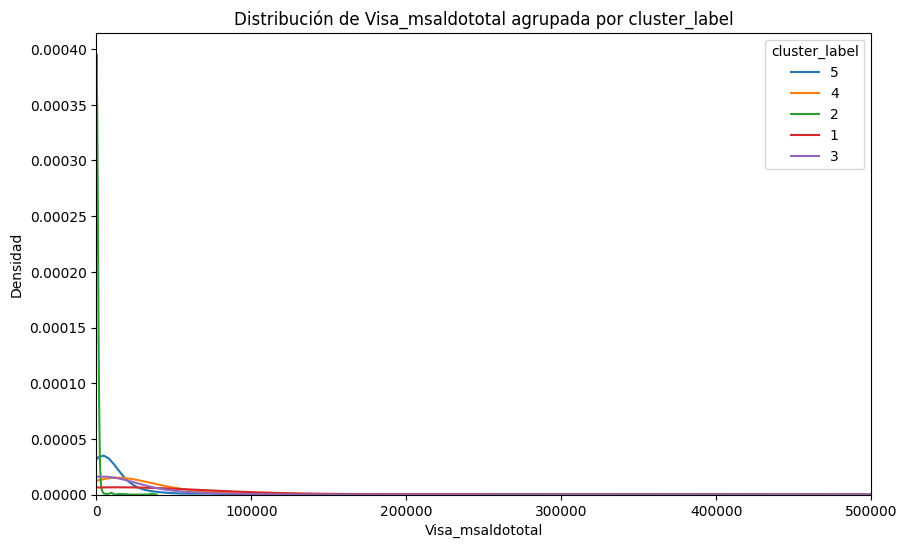

In [316]:
plot_grouped_histogram(df_last_month_history, "Visa_msaldototal", "cluster_label", xlim=(-100, 500000))